In [12]:
import polars as pd

data = pd.read_csv("data/data.csv")

print(data.columns)

# Average of "Bottom Flywheel Measured Velocity" and "Top Flywheel Measured Velocity"
flywheel_vel = (data["Bottom Flywheel Measured Velocity"] + data["Top Flywheel Measured Velocity"]) / 2
# Total of "Bottom Flywheel Current" and "Top Flywheel Current"
flywheel_current = data["Bottom Flywheel Current"] + data["Top Flywheel Current"]

azimuth_vel = data["Azimuth Measured Velocity"]
azimuth_current = data["Azimuth Current"]

hood_vel = data["Hood Measured Velocity"]
hood_current = data["Hood Current"]

total_current = flywheel_current + azimuth_current + hood_current

['Top Flywheel Target Velocity', 'Top Flywheel Measured Velocity', 'Top Flywheel Current', 'Bottom Flywheel Target Velocity', 'Bottom Flywheel Measured Velocity', 'Bottom Flywheel Current', 'Azimuth Target Velocity', 'Azimuth Measured Velocity', 'Azimuth Current', 'Hood Target Velocity', 'Hood Measured Velocity', 'Hood Current', '']


In [13]:
# %pip install matplotlib "nbformat>=4.2.0"

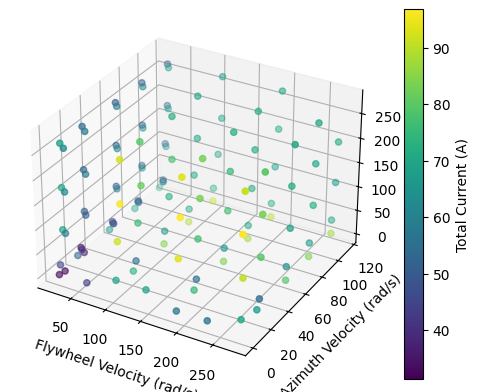

In [14]:
# Plot in 3D with velocities on each axis and current as the color
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
scat = ax.scatter(flywheel_vel, azimuth_vel, hood_vel, c=total_current, cmap="viridis")
ax.set_xlabel("Flywheel Velocity (rad/s)")
ax.set_ylabel("Azimuth Velocity (rad/s)")
ax.set_zlabel("Hood Velocity (rad/s)")
fig.colorbar(scat, label="Total Current (A)")
plt.show()

In [15]:
# Interactive plot with the ability to rotate and zoom
import plotly.express as px

fig = px.scatter_3d(
    x=flywheel_vel,
    y=azimuth_vel,
    z=hood_vel,
    color=total_current,
    labels={
        "x": "Flywheel Velocity (rad/s)",
        "y": "Azimuth Velocity (rad/s)",
        "z": "Hood Velocity (rad/s)",
        "color": "Total Current (A)",
        "hover_data": "Current (A)",
    },
    # Individual currents
    hover_data={
        "Flywheel Current (A)": flywheel_current,
        "Azimuth Current (A)": azimuth_current,
        "Hood Current (A)": hood_current,
    },
    title="Turret Motor Velocities and Currents"
)
fig.show()

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

X = pd.DataFrame({
    "flywheel_vel": flywheel_vel,
    "azimuth_vel": azimuth_vel,
    "hood_vel": hood_vel
})

def fit_model(current_set: pd.Series, degree=2) -> tuple[PolynomialFeatures, LinearRegression]:
    y = current_set
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    return (poly, model)

In [17]:
def create_equation(poly: PolynomialFeatures, model: LinearRegression) -> str:
    equation = "y = "

    for i, term in enumerate(poly.powers_):
        coeff = model.coef_[i] if i > 0 else model.intercept_
        if coeff == 0:
            continue
        term_str = " * ".join(
            f"{var}^{power}" if power > 1 else f"{var}" if power == 1 else ""
            for var, power in zip(X.columns, term)
        ).strip(" *").replace(" *  * ", " * ")
        if term_str == "":
            equation += f"{coeff:.8f}"
        else:
            equation += f"{coeff:.8f} * {term_str}"
        if i < len(poly.powers_) - 1:
            equation += " + "
    
    return equation

In [25]:
# Compute R^2 score for the model
from sklearn.metrics import r2_score

def score_model_r2(current_set: pd.Series, poly: PolynomialFeatures, model: LinearRegression):
    X_poly = poly.transform(X)
    y_pred = model.predict(X_poly)
    return r2_score(current_set, y_pred)

In [29]:
# 2D cross-section (flywheel vs azimuth) with a slider for hood velocity
import numpy as np
import plotly.graph_objects as go

# Predict total current for a grid of velocities
def visualize(current_set: pd.Series, poly: PolynomialFeatures, model: LinearRegression):
    flywheel_vel_grid = np.linspace(flywheel_vel.min(), flywheel_vel.max(), 32)
    azimuth_vel_grid = np.linspace(azimuth_vel.min(), azimuth_vel.max(), 32)
    hood_vel_grid = np.linspace(hood_vel.min(), hood_vel.max(), 32)

    flywheel_vel_grid, azimuth_vel_grid, hood_vel_grid = np.meshgrid(flywheel_vel_grid, azimuth_vel_grid, hood_vel_grid)

    X_grid = pd.DataFrame({
        "flywheel_vel": flywheel_vel_grid.flatten(),
        "azimuth_vel": azimuth_vel_grid.flatten(),
        "hood_vel": hood_vel_grid.flatten(),
    })

    X_grid_poly = poly.transform(X_grid)
    y_grid_pred = model.predict(X_grid_poly)

    # Plot the predicted surface
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    # Squares to represent real data and circles to represent the model
    vmin = 0
    # vmax = 100
    vmax = max(current_set.max(), y_grid_pred.max())
    scat = ax.scatter(flywheel_vel, azimuth_vel, hood_vel, c=current_set, cmap="viridis", label="Data", marker="s", vmin=vmin, vmax=vmax)
    ax.scatter(X_grid["flywheel_vel"], X_grid["azimuth_vel"], X_grid["hood_vel"], c=y_grid_pred, cmap="viridis", label="Model", marker="o", vmin=vmin, vmax=vmax, alpha=0.02)

    ax.set_xlabel("Flywheel Velocity (rad/s)")
    ax.set_ylabel("Azimuth Velocity (rad/s)")
    ax.set_zlabel("Hood Velocity (rad/s)")
    ax.legend()
    plt.show()

    # flattened grid arrays and predictions (already exist in the notebook)
    fx = flywheel_vel_grid.flatten()
    ax = hood_vel_grid.flatten()
    hx = azimuth_vel_grid.flatten()
    pred = y_grid_pred

    # unique hood levels (slider steps)
    hood_levels = np.unique(hx)

    # build one trace per hood slice (only the first visible initially)
    pred_traces = []
    for i, h in enumerate(hood_levels):
        mask = hx == h
        pred_traces.append(go.Scatter(
            x=fx[mask],
            y=ax[mask],
            mode="markers",
            marker=dict(
                color=pred[mask],
                colorscale="Viridis",
                cmin=vmin,
                cmax=vmax,
                size=6
            ),
            name=f"Model (azimuth={h:06.2f})",
            visible=(i == 0),
            hovertemplate="Flywheel: %{x:.1f}<br>Hood: %{y:.1f}<br>Pred: %{marker.color:.2f}<extra></extra>",
        ))

        # Actual data, with opacity scaled by how close the data slice is to our slice
        pred_traces.append(go.Scatter(
            x=flywheel_vel,
            y=hood_vel,
            mode="markers",
            marker=dict(
                color=total_current,
                colorscale="Viridis",
                cmin=vmin,
                cmax=vmax,
                size=8,
                opacity=np.exp(-((azimuth_vel - h) ** 2) / (2 * 8**2))
            ),
            name="Data",
            hovertemplate="Flywheel: %{x:.1f}<br>Hood: %{y:.1f}<br>Total Current: %{marker.color:.2f}<extra></extra>",
        ))

    fig2d = go.Figure(data=pred_traces)

    # slider steps: toggle visibility of the model traces, keep data_trace visible
    steps = []
    n_model = len(pred_traces)
    for i, h in enumerate(hood_levels):
        vis = [False] * n_model
        vis[2 * i] = True  # model trace for this hood slice
        vis[2 * i + 1] = True  # data trace
        steps.append(
            dict(
                method="update",
                args=[{"visible": vis}, {"title": f"Azimuth slice = {h:3.1f}"}],
                label=f"{h:.0f}",
            )
        )

    sliders = [dict(active=0, currentvalue={"prefix": "Azimuth = "}, pad={"t": 10}, steps=steps)]

    fig2d.update_layout(
        title=f"Hood slice = {hood_levels[0]:.1f}",
        xaxis_title="Flywheel Velocity (rad/s)",
        yaxis_title="Hood Velocity (rad/s)",
        sliders=sliders,
        height=800,
        width=1050
    )

    fig2d.show()

In [26]:
def log_model_info(model_name: str, current_set: pd.Series, poly: PolynomialFeatures, model: LinearRegression):
    print(f"{model_name}:")
    equation = create_equation(poly, model)
    print(f"  Model equation: {equation}")

    r2 = score_model_r2(current_set, poly, model)
    print(f"  R^2 score: {r2:.4f}")

In [30]:
# Fit for each of the three current sets
flywheel_poly, flywheel_model = fit_model(flywheel_current)
azimuth_poly, azimuth_model = fit_model(azimuth_current)
hood_poly, hood_model = fit_model(hood_current)
total_poly, total_model = fit_model(total_current)

log_model_info("Flywheel Current", flywheel_current, flywheel_poly, flywheel_model)
log_model_info("Azimuth Current", azimuth_current, azimuth_poly, azimuth_model)
log_model_info("Hood Current", hood_current, hood_poly, hood_model)

Flywheel Current:
  Model equation: y = 9.72059590 + 0.40241220 * flywheel_vel + -0.08996392 * azimuth_vel + -0.04754386 * hood_vel + -0.00094384 * flywheel_vel^2 + 0.00027572 * flywheel_vel * azimuth_vel + 0.00001946 * flywheel_vel * hood_vel + 0.00009773 * azimuth_vel^2 + 0.00006386 * azimuth_vel * hood_vel + 0.00003627 * hood_vel^2
  R^2 score: 0.9166
Azimuth Current:
  Model equation: y = 12.28423483 + -0.01807123 * flywheel_vel + 0.26914493 * azimuth_vel + -0.02494931 * hood_vel + 0.00007737 * flywheel_vel^2 + -0.00095989 * flywheel_vel * azimuth_vel + 0.00013203 * flywheel_vel * hood_vel + 0.00100470 * azimuth_vel^2 + -0.00150827 * azimuth_vel * hood_vel + 0.00015894 * hood_vel^2
  R^2 score: 0.7533
Hood Current:
  Model equation: y = 9.36136869 + -0.01273649 * flywheel_vel + -0.12399537 * azimuth_vel + 0.22395447 * hood_vel + -0.00001040 * flywheel_vel^2 + 0.00014352 * flywheel_vel * azimuth_vel + -0.00018331 * flywheel_vel * hood_vel + 0.00055080 * azimuth_vel^2 + -0.00014823 *

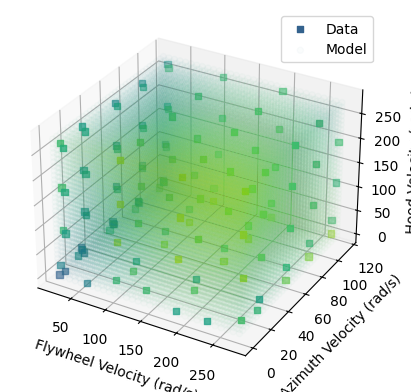

In [31]:
visualize(total_current, total_poly, total_model)